In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os
HERE = %pwd
sys.path.append(os.path.dirname(HERE))

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

import numpy as np
import pandas as pd
import torch
import pickle
from transformers import AutoModel, AutoTokenizer

from src import utils
from src.attention_analysis import (
    make_results,
    load_job_data, load_ml_data, load_ard_data,
    compare_output_embeddings, analyze_attention_weights,
    evaluate_task_performance, compute_content_varied_similarity,
    plot_similarity_comparison, compute_pv_cv_cos_sims,
)
from src.visualizer import (
    plot_content_attn_similarity,
    plot_content_attn_similarity_multi,
)
from src.table_utils import fmt, save_table

rng           = utils.set_seed()
dir_parent    = utils.dir_parent
version_exp   = utils.version_exp
dir_workspace = f"{dir_parent}/research/TFCSR"
device        = utils.device

# Shared font sizes for figures
FS = dict(title=13, axis=12, tick=11, legend=11, annot=12, annot_small=10)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Model Configurations

In [2]:
MODEL_CONFIGS = {
    "Qwen3-Embedding-8B": {
        "hf_name":   "Qwen/Qwen3-Embedding-8B",
        "model_path": f"{dir_parent}/models/embedding_models/Qwen/Qwen3-Embedding-8B",
        "csv_slug":  "Qwen_Qwen3-Embedding-8B",
        "d_prefix": {
            "default"  : "Given a web search query, retrieve relevant passages that answer the query",
            "product"  : "Given user information, retrieve relevant items that are similar to the item",
            "user"     : "Given user information, retrieve relevant items that the target user would like",
            "ablation" : 'Given a web search query, retrieve "irrelevant" passages that answer the query',
        },
    },
    "Nemotron-8B": {
        "hf_name":   "nvidia/llama-embed-nemotron-8b",
        "model_path": f"{dir_parent}/models/embedding_models/nvidia/llama-embed-nemotron-8b",
        "csv_slug":  "nvidia_llama-embed-nemotron-8b",
        "d_prefix": {
            "default"  : "Given a question, retrieve passages that answer the question",
            "product"  : "Given user information, retrieve relevant items that are similar to the item",
            "user"     : "Given user information, retrieve relevant items that the target user would like",
            "ablation" : "Given a question, retrieve passages that DO NOT answer the question",
        },
    },
}

model_keys = list(MODEL_CONFIGS.keys())
print("Models:", model_keys)

Models: ['Qwen3-Embedding-8B', 'Nemotron-8B']


# Analysis

  MODEL: Qwen3-Embedding-8B

--- Job ---
Job: 500 users (CSV valid: 500)


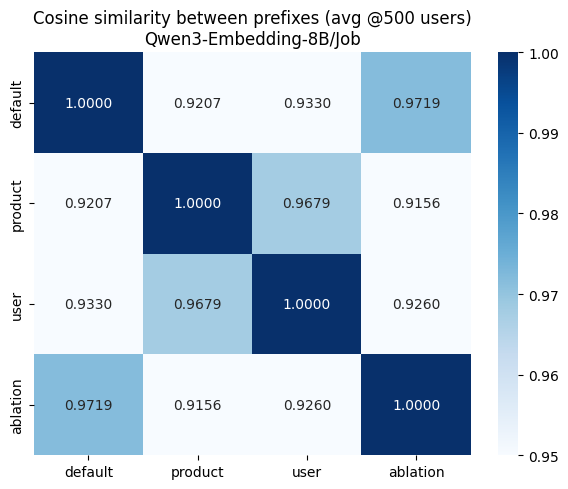

Cosine similarity vs prefix=default (Qwen3-Embedding-8B/Job, mean ± std):
  default vs product   : 0.920714 ± 0.010601
  default vs user      : 0.933047 ± 0.009936
  default vs ablation  : 0.971860 ± 0.004983
Content-varied similarity (Qwen3-Embedding-8B/Job, same prefix, different users):
  prefix=default   : 0.5262 ± 0.0710  (n_pairs=124750)
  prefix=product   : 0.6584 ± 0.0614  (n_pairs=124750)
  prefix=user      : 0.6275 ± 0.0633  (n_pairs=124750)
  prefix=ablation  : 0.5575 ± 0.0662  (n_pairs=124750)

--- MovieLens ---
MovieLens: 500 users (CSV valid: 500)


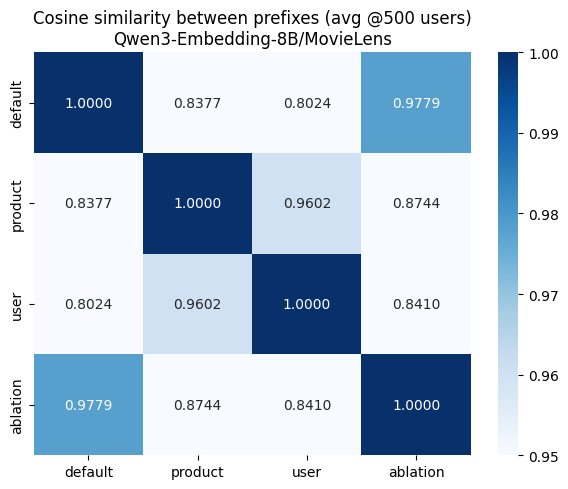

Cosine similarity vs prefix=default (Qwen3-Embedding-8B/MovieLens, mean ± std):
  default vs product   : 0.837670 ± 0.016022
  default vs user      : 0.802392 ± 0.023753
  default vs ablation  : 0.977934 ± 0.003995
Content-varied similarity (Qwen3-Embedding-8B/MovieLens, same prefix, different users):
  prefix=default   : 0.5309 ± 0.1448  (n_pairs=124750)
  prefix=product   : 0.6766 ± 0.1062  (n_pairs=124750)
  prefix=user      : 0.6315 ± 0.1169  (n_pairs=124750)
  prefix=ablation  : 0.5604 ± 0.1343  (n_pairs=124750)

--- ARD_CDs ---
ARD_CDs_and_Vinyl: 500 users (CSV valid: 500, concat_5-sample)


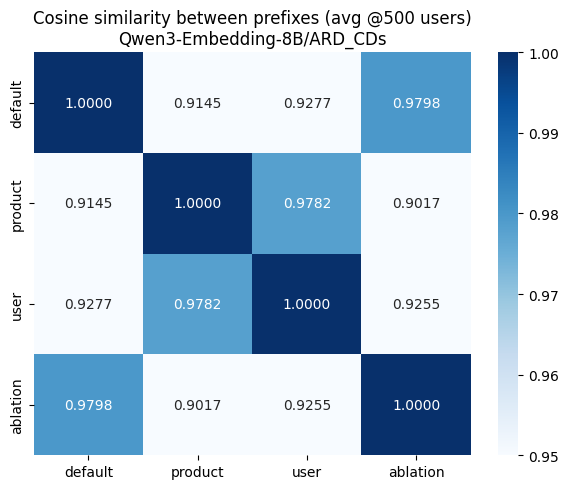

Cosine similarity vs prefix=default (Qwen3-Embedding-8B/ARD_CDs, mean ± std):
  default vs product   : 0.914535 ± 0.015114
  default vs user      : 0.927681 ± 0.015075
  default vs ablation  : 0.979839 ± 0.004770
Content-varied similarity (Qwen3-Embedding-8B/ARD_CDs, same prefix, different users):
  prefix=default   : 0.4208 ± 0.0741  (n_pairs=124750)
  prefix=product   : 0.5708 ± 0.0807  (n_pairs=124750)
  prefix=user      : 0.5512 ± 0.0730  (n_pairs=124750)
  prefix=ablation  : 0.4405 ± 0.0638  (n_pairs=124750)

--- ARD_Movies ---
ARD_Movies_and_TV: 500 users (CSV valid: 500, concat_5-sample)


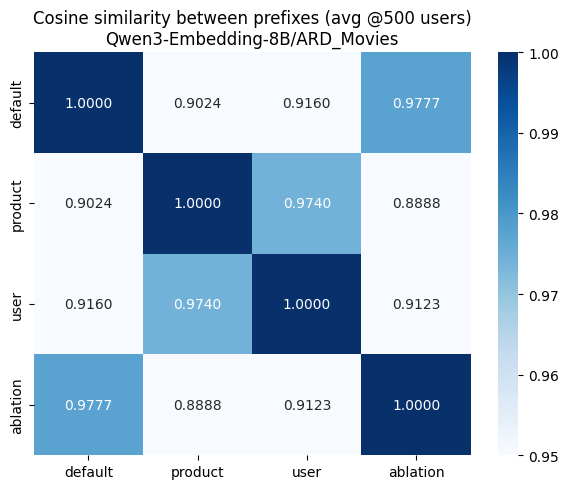

Cosine similarity vs prefix=default (Qwen3-Embedding-8B/ARD_Movies, mean ± std):
  default vs product   : 0.902355 ± 0.016769
  default vs user      : 0.915958 ± 0.020237
  default vs ablation  : 0.977701 ± 0.006245
Content-varied similarity (Qwen3-Embedding-8B/ARD_Movies, same prefix, different users):
  prefix=default   : 0.4068 ± 0.0750  (n_pairs=124750)
  prefix=product   : 0.5656 ± 0.0815  (n_pairs=124750)
  prefix=user      : 0.5595 ± 0.0758  (n_pairs=124750)
  prefix=ablation  : 0.4301 ± 0.0640  (n_pairs=124750)

--- ARD_Toys ---
ARD_Toys_and_Games: 500 users (CSV valid: 500, concat_5-sample)


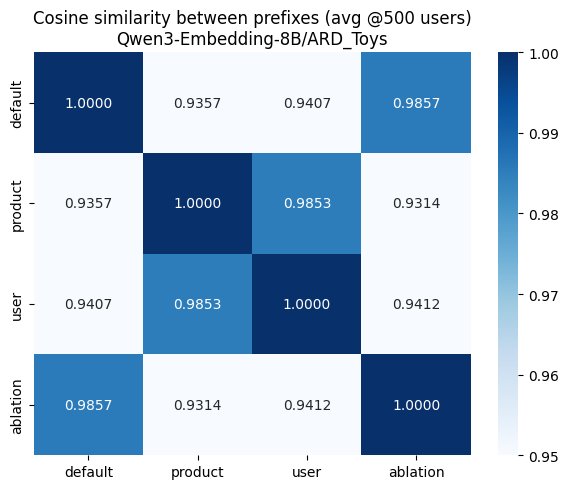

Cosine similarity vs prefix=default (Qwen3-Embedding-8B/ARD_Toys, mean ± std):
  default vs product   : 0.935679 ± 0.014584
  default vs user      : 0.940661 ± 0.020466
  default vs ablation  : 0.985667 ± 0.004157
Content-varied similarity (Qwen3-Embedding-8B/ARD_Toys, same prefix, different users):
  prefix=default   : 0.4934 ± 0.1006  (n_pairs=124750)
  prefix=product   : 0.6520 ± 0.0922  (n_pairs=124750)
  prefix=user      : 0.6321 ± 0.0869  (n_pairs=124750)
  prefix=ablation  : 0.5072 ± 0.0877  (n_pairs=124750)

--- ARD_Sports ---
ARD_Sports_and_Outdoors: 500 users (CSV valid: 500, concat_5-sample)


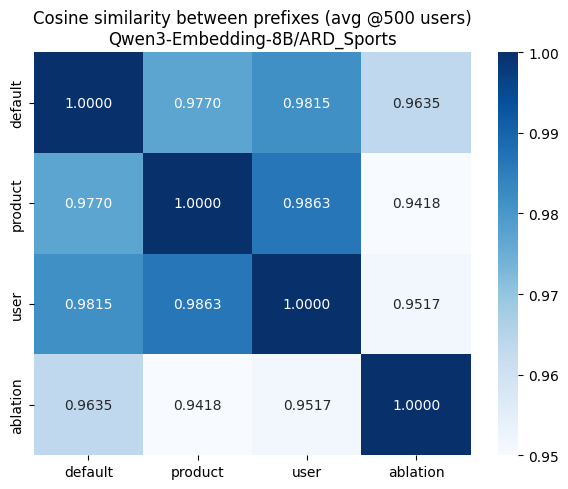

Cosine similarity vs prefix=default (Qwen3-Embedding-8B/ARD_Sports, mean ± std):
  default vs product   : 0.976987 ± 0.007036
  default vs user      : 0.981499 ± 0.007160
  default vs ablation  : 0.963520 ± 0.009382
Content-varied similarity (Qwen3-Embedding-8B/ARD_Sports, same prefix, different users):
  prefix=default   : 0.5425 ± 0.0802  (n_pairs=124750)
  prefix=product   : 0.6251 ± 0.0778  (n_pairs=124750)
  prefix=user      : 0.5864 ± 0.0789  (n_pairs=124750)
  prefix=ablation  : 0.5088 ± 0.0749  (n_pairs=124750)
  MODEL: Nemotron-8B

--- Job ---
Job: 500 users (CSV valid: 500)


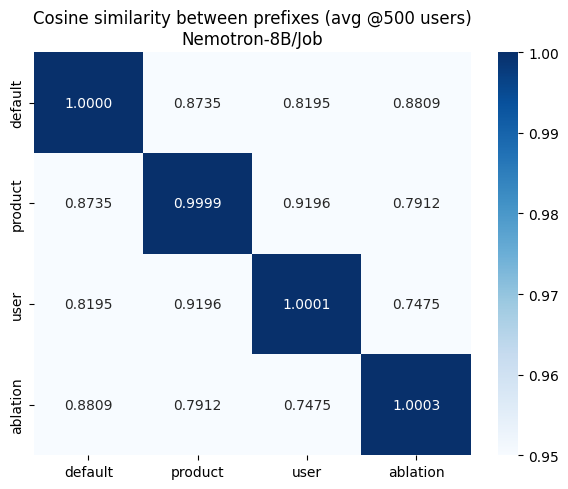

Cosine similarity vs prefix=default (Nemotron-8B/Job, mean ± std):
  default vs product   : 0.873484 ± 0.011899
  default vs user      : 0.819502 ± 0.017985
  default vs ablation  : 0.880890 ± 0.021319
Content-varied similarity (Nemotron-8B/Job, same prefix, different users):
  prefix=default   : 0.5382 ± 0.0692  (n_pairs=124750)
  prefix=product   : 0.6418 ± 0.0691  (n_pairs=124750)
  prefix=user      : 0.6972 ± 0.0645  (n_pairs=124750)
  prefix=ablation  : 0.6701 ± 0.0528  (n_pairs=124750)

--- MovieLens ---
MovieLens: 500 users (CSV valid: 500)


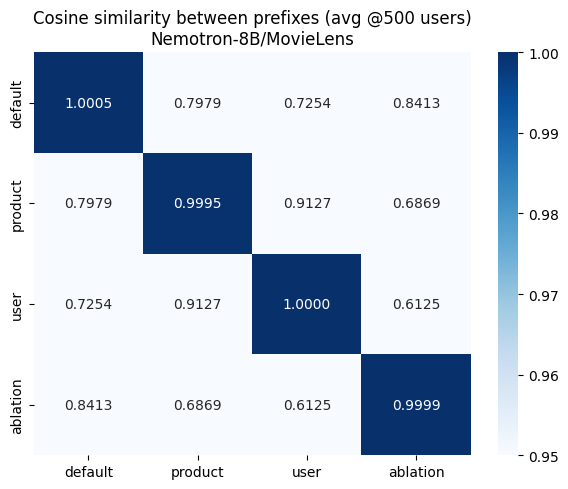

Cosine similarity vs prefix=default (Nemotron-8B/MovieLens, mean ± std):
  default vs product   : 0.797898 ± 0.013552
  default vs user      : 0.725355 ± 0.018510
  default vs ablation  : 0.841275 ± 0.016461
Content-varied similarity (Nemotron-8B/MovieLens, same prefix, different users):
  prefix=default   : 0.4535 ± 0.1797  (n_pairs=124750)
  prefix=product   : 0.6096 ± 0.1400  (n_pairs=124750)
  prefix=user      : 0.6024 ± 0.1444  (n_pairs=124750)
  prefix=ablation  : 0.6790 ± 0.1019  (n_pairs=124750)

--- ARD_CDs ---
ARD_CDs_and_Vinyl: 500 users (CSV valid: 500, concat_5-sample)


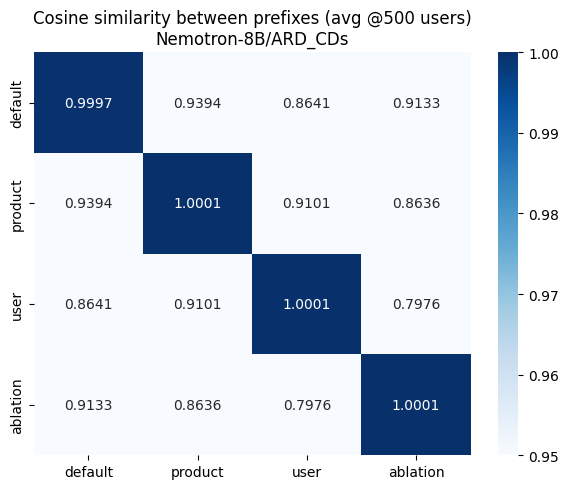

Cosine similarity vs prefix=default (Nemotron-8B/ARD_CDs, mean ± std):
  default vs product   : 0.939439 ± 0.013091
  default vs user      : 0.864146 ± 0.022697
  default vs ablation  : 0.913326 ± 0.014630
Content-varied similarity (Nemotron-8B/ARD_CDs, same prefix, different users):
  prefix=default   : 0.3518 ± 0.0604  (n_pairs=124750)
  prefix=product   : 0.3811 ± 0.0604  (n_pairs=124750)
  prefix=user      : 0.5165 ± 0.0539  (n_pairs=124750)
  prefix=ablation  : 0.4716 ± 0.0523  (n_pairs=124750)

--- ARD_Movies ---
ARD_Movies_and_TV: 500 users (CSV valid: 500, concat_5-sample)


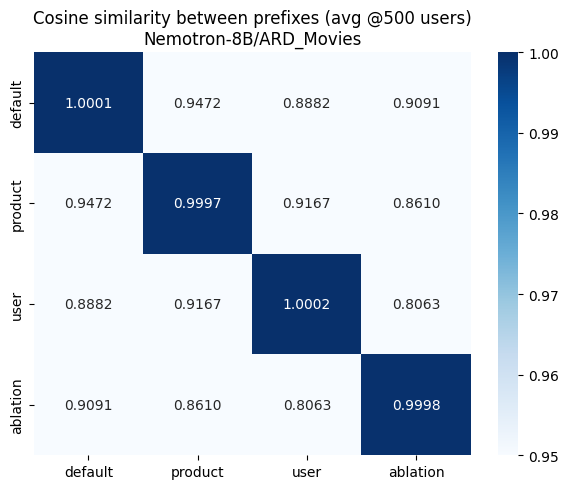

Cosine similarity vs prefix=default (Nemotron-8B/ARD_Movies, mean ± std):
  default vs product   : 0.947156 ± 0.011161
  default vs user      : 0.888197 ± 0.019564
  default vs ablation  : 0.909060 ± 0.013830
Content-varied similarity (Nemotron-8B/ARD_Movies, same prefix, different users):
  prefix=default   : 0.3821 ± 0.0701  (n_pairs=124750)
  prefix=product   : 0.3875 ± 0.0653  (n_pairs=124750)
  prefix=user      : 0.5064 ± 0.0579  (n_pairs=124750)
  prefix=ablation  : 0.4929 ± 0.0621  (n_pairs=124750)

--- ARD_Toys ---
ARD_Toys_and_Games: 500 users (CSV valid: 500, concat_5-sample)


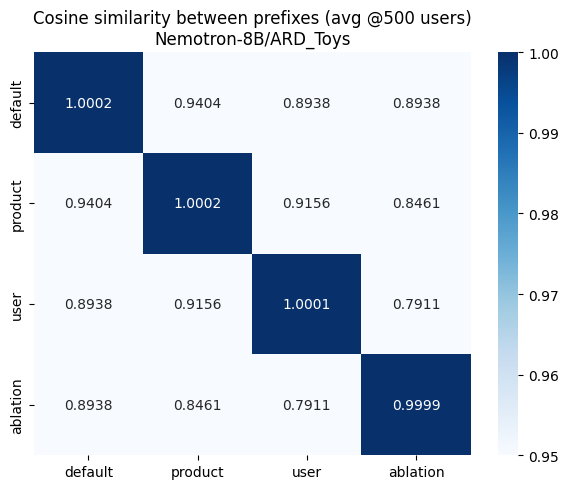

Cosine similarity vs prefix=default (Nemotron-8B/ARD_Toys, mean ± std):
  default vs product   : 0.940412 ± 0.013789
  default vs user      : 0.893795 ± 0.024448
  default vs ablation  : 0.893827 ± 0.013884
Content-varied similarity (Nemotron-8B/ARD_Toys, same prefix, different users):
  prefix=default   : 0.4599 ± 0.1047  (n_pairs=124750)
  prefix=product   : 0.4593 ± 0.0895  (n_pairs=124750)
  prefix=user      : 0.5726 ± 0.0860  (n_pairs=124750)
  prefix=ablation  : 0.5699 ± 0.0766  (n_pairs=124750)

--- ARD_Sports ---
ARD_Sports_and_Outdoors: 500 users (CSV valid: 500, concat_5-sample)


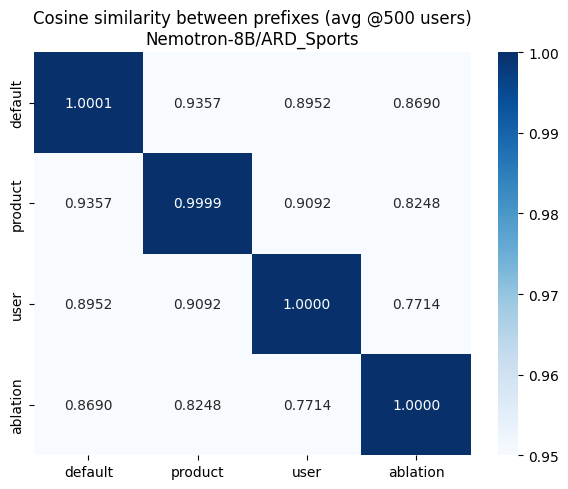

Cosine similarity vs prefix=default (Nemotron-8B/ARD_Sports, mean ± std):
  default vs product   : 0.935705 ± 0.012527
  default vs user      : 0.895165 ± 0.017881
  default vs ablation  : 0.869042 ± 0.016487
Content-varied similarity (Nemotron-8B/ARD_Sports, same prefix, different users):
  prefix=default   : 0.4245 ± 0.0812  (n_pairs=124750)
  prefix=product   : 0.4265 ± 0.0718  (n_pairs=124750)
  prefix=user      : 0.5236 ± 0.0719  (n_pairs=124750)
  prefix=ablation  : 0.5712 ± 0.0639  (n_pairs=124750)


In [3]:
# load precomputed embeddings; compute cosine sims under prefix/content perturbations

ds_list = [
    ("Job",        lambda cfg, w, v: load_job_data(cfg, w, v)),
    ("MovieLens",  lambda cfg, w, v: load_ml_data(cfg, w, v)),
    ("ARD_CDs",    lambda cfg, w, v: load_ard_data(cfg, w, v, "ARD_CDs_and_Vinyl")),
    ("ARD_Movies", lambda cfg, w, v: load_ard_data(cfg, w, v, "ARD_Movies_and_TV")),
    ("ARD_Toys",   lambda cfg, w, v: load_ard_data(cfg, w, v, "ARD_Toys_and_Games")),
    ("ARD_Sports", lambda cfg, w, v: load_ard_data(cfg, w, v, "ARD_Sports_and_Outdoors")),
]

all_results = {}

for model_key in model_keys:
    cfg              = MODEL_CONFIGS[model_key]
    prefix_names     = list(cfg["d_prefix"].keys())
    compare_prefixes = [p for p in prefix_names if p != "default"]

    print("=" * 80)
    print(f"  MODEL: {model_key}")
    print("=" * 80)

    model_results = {}
    for ds_name, load_fn in ds_list:
        print(f"\n--- {ds_name} ---")
        try:
            users, user_texts, users_valid, d_flag, cand, emb_csv, emb_dir = \
                load_fn(cfg, dir_workspace, version_exp)
        except FileNotFoundError as e:
            print(f"skip {ds_name}: {e}")
            continue

        emb, sim = compare_output_embeddings(
            emb_csv, len(users_valid), prefix_names, compare_prefixes,
            label=f"{model_key}/{ds_name}",
        )
        content_varied = compute_content_varied_similarity(
            emb_csv, len(users_valid), prefix_names,
            label=f"{model_key}/{ds_name}",
        )
        prefix_varied_sims = {
            p: (emb_csv["default"] * emb_csv[p]).sum(dim=1).numpy()
            for p in compare_prefixes
        }

        model_results[ds_name] = {
            "emb":                emb,
            "sim":                sim,
            "content_varied":     content_varied,
            "prefix_varied_sims": prefix_varied_sims,
            "users_valid":        users_valid,
            "user_texts":         user_texts,
        }

    all_results[model_key] = model_results

# Summary

In [4]:
for model_key, model_res in all_results.items():
    cfg              = MODEL_CONFIGS[model_key]
    compare_prefixes = [p for p in cfg["d_prefix"] if p != "default"]
    ds_names         = ["Job", "MovieLens", "ARD_CDs"]

    print("=" * 70)
    print(f"{model_key}: output embedding cosine similarity vs default")
    print("=" * 70)
    for ds_name in ds_names:
        if ds_name not in model_res:
            continue
        emb = model_res[ds_name]["emb"]
        print(f"\n  [{ds_name}]")
        for p in compare_prefixes:
            sims = (emb["default"] * emb[p]).sum(dim=1).numpy()
            print(f"    default vs {p:<10s}: {sims.mean():.6f} ± {sims.std():.6f}")

    print()
    print("=" * 70)
    print(f"{model_key}: prefix-varied (PV) vs content-varied (CV), embedding-level")
    print("=" * 70)
    for ds_name in ds_names:
        if ds_name not in model_res:
            continue
        cv = model_res[ds_name]["content_varied"]
        print(f"\n  [{ds_name}]")
        print(f"    CV (default): {cv['default']['mean']:.4f} ± {cv['default']['std']:.4f}")
        for p in compare_prefixes:
            pv = model_res[ds_name]["prefix_varied_sims"][p]
            ratio = pv.mean() / cv['default']['mean']
            print(f"    PV ({p:<10s}): {pv.mean():.4f} ± {pv.std():.4f}  "
                  f"(ratio: {ratio:.2f}x)")

Qwen3-Embedding-8B: output embedding cosine similarity vs default

  [Job]
    default vs product   : 0.920714 ± 0.010601
    default vs user      : 0.933047 ± 0.009936
    default vs ablation  : 0.971860 ± 0.004983

  [MovieLens]
    default vs product   : 0.837670 ± 0.016022
    default vs user      : 0.802392 ± 0.023753
    default vs ablation  : 0.977934 ± 0.003995

  [ARD_CDs]
    default vs product   : 0.914535 ± 0.015114
    default vs user      : 0.927681 ± 0.015075
    default vs ablation  : 0.979839 ± 0.004770

Qwen3-Embedding-8B: prefix-varied (PV) vs content-varied (CV), embedding-level

  [Job]
    CV (default): 0.5262 ± 0.0710
    PV (product   ): 0.9207 ± 0.0106  (ratio: 1.75x)
    PV (user      ): 0.9330 ± 0.0099  (ratio: 1.77x)
    PV (ablation  ): 0.9719 ± 0.0050  (ratio: 1.85x)

  [MovieLens]
    CV (default): 0.5309 ± 0.1448
    PV (product   ): 0.8377 ± 0.0160  (ratio: 1.58x)
    PV (user      ): 0.8024 ± 0.0238  (ratio: 1.51x)
    PV (ablation  ): 0.9779 ± 0.0040 

# PV / CV Embedding Similarity Figure

Saved as `content_emb_similarity.pdf`.

Qwen3-Embedding-8B/ARD_Sports  PV[product]: 0.9770±0.0070  PV[user]: 0.9815±0.0072  PV[ablation]: 0.9635±0.0094  CV: 0.5430±0.0817
Qwen3-Embedding-8B/ARD_Toys  PV[product]: 0.9357±0.0146  PV[user]: 0.9407±0.0205  PV[ablation]: 0.9857±0.0042  CV: 0.4915±0.1006
Qwen3-Embedding-8B/ARD_Movies  PV[product]: 0.9024±0.0168  PV[user]: 0.9160±0.0202  PV[ablation]: 0.9777±0.0062  CV: 0.3995±0.0767
Qwen3-Embedding-8B/ARD_CDs  PV[product]: 0.9145±0.0151  PV[user]: 0.9277±0.0151  PV[ablation]: 0.9798±0.0048  CV: 0.4197±0.0757
Qwen3-Embedding-8B/MovieLens  PV[product]: 0.8377±0.0160  PV[user]: 0.8024±0.0238  PV[ablation]: 0.9779±0.0040  CV: 0.5361±0.1485
Qwen3-Embedding-8B/Job  PV[product]: 0.9207±0.0106  PV[user]: 0.9330±0.0099  PV[ablation]: 0.9719±0.0050  CV: 0.5250±0.0689
Nemotron-8B/ARD_Sports  PV[product]: 0.9357±0.0124  PV[user]: 0.8951±0.0177  PV[ablation]: 0.8690±0.0164  CV: 0.4240±0.0799
Nemotron-8B/ARD_Toys  PV[product]: 0.9402±0.0137  PV[user]: 0.8937±0.0244  PV[ablation]: 0.8938±0.0138 

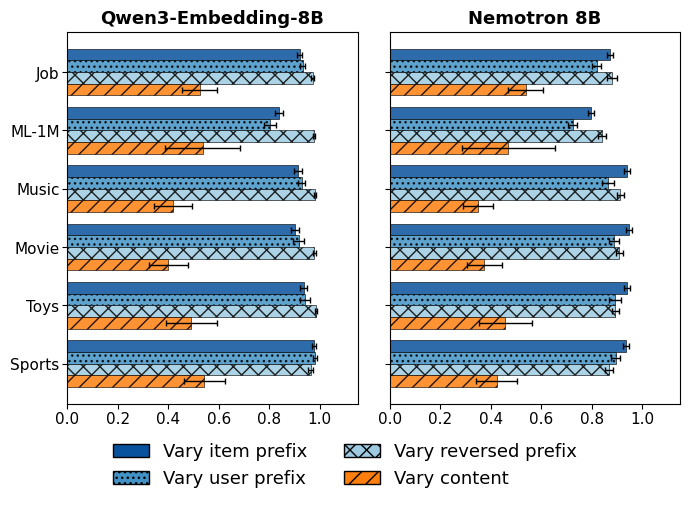

In [5]:
from src.attention_analysis import compute_pv_cv_emb_sims

# dataset roster for figure and appendix table
ds_list_labels = [
    ("Job",         "Job"),
    ("MovieLens",   "ML-1M"),
    ("ARD_CDs",     "Music"),
    ("ARD_Movies",  "Movie"),
    ("ARD_Toys",    "Toys"),
    ("ARD_Sports",  "Sports"),
]
compare_prefixes_pv = ["product", "user", "ablation"]

dir_figs = f"{dir_workspace}/figs"
os.makedirs(dir_figs, exist_ok=True)

# PV/CV cosine sims per (model, dataset)
pv_cv_emb_by_model = {}

for model_key in model_keys:
    model_res = all_results.get(model_key, {})
    pv_cv_emb = {}
    # reversed roster: y grows upward, so inserting Sports first puts Job at the
    # top of the figure without inverting the axis
    for ds_name, ds_label in ds_list_labels[::-1]:
        if ds_name not in model_res:
            print(f"skip (no all_results): {model_key}/{ds_name}")
            continue
        emb_by_prefix = model_res[ds_name]["emb"]
        result = compute_pv_cv_emb_sims(
            emb_by_prefix, compare_prefixes=compare_prefixes_pv
        )
        pv_cv_emb[ds_name] = result
        pv_txt = "  ".join(
            f"PV[{p}]: {result['pv_by_prefix'][p].mean():.4f}±{result['pv_by_prefix'][p].std():.4f}"
            for p in compare_prefixes_pv
        )
        print(f"{model_key}/{ds_name}  {pv_txt}  "
              f"CV: {result['cv'].mean():.4f}±{result['cv'].std():.4f}")

    pv_cv_emb_by_model[model_key] = pv_cv_emb


# figure
from matplotlib.patches import Patch

figsize      = (7.0, 5.2)
xlim         = (0.0, 1.15)
model_labels = ["Qwen3-Embedding-8B", "Nemotron 8B"]
height       = 0.20

# one bar per entry within a dataset group, ordered top to bottom.
# prefix=None marks the content-varied (CV) reference series.
# Every series carries a distinct hatch so the four bars stay separable in
# grayscale printing and for color-vision-deficient readers; color alone is
# redundant encoding. The darkest series stays solid because a black hatch on
# a dark fill has too little contrast to read.
bar_series = [
    {"prefix": "product",  "label": "Vary item prefix",     "color": "#08519c",    "hatch": ""},
    {"prefix": "user",     "label": "Vary user prefix",     "color": "#4292c6",    "hatch": "..."},
    {"prefix": "ablation", "label": "Vary reversed prefix", "color": "#9ecae1",    "hatch": "xx"},
    {"prefix": None,       "label": "Vary content",         "color": "tab:orange", "hatch": "//"},
]

models   = list(pv_cv_emb_by_model.keys())
n_models = len(models)
n_series = len(bar_series)

fig, axes = plt.subplots(1, n_models, figsize=figsize, sharey=True)
if n_models == 1:
    axes = [axes]

for ax, mkey, mlabel in zip(axes, models, model_labels):
    pv_cv_dict = pv_cv_emb_by_model[mkey]
    datasets   = list(pv_cv_dict.keys())
    labels     = [dict(ds_list_labels)[ds] for ds in datasets]
    y          = np.arange(len(datasets))

    for k, series in enumerate(bar_series):
        # y grows upward (datasets were inserted in reverse order), so the first
        # series needs the largest offset to sit at the top of its group
        offset = ((n_series - 1) / 2 - k) * height
        sims   = [
            pv_cv_dict[ds]["cv"] if series["prefix"] is None
            else pv_cv_dict[ds]["pv_by_prefix"][series["prefix"]]
            for ds in datasets
        ]
        means = np.array([s.mean() for s in sims])
        stds  = np.array([s.std()  for s in sims])
        ax.barh(y + offset, means, height, xerr=stds,
                color=series["color"], hatch=series["hatch"],
                edgecolor="black", linewidth=0.5,  # hatch is drawn in the edge color
                capsize=2, error_kw={"linewidth": 1.0}, alpha=0.85)

    ax.set_title(mlabel, fontsize=FS["title"], fontweight="bold")
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=FS["tick"])
    ax.tick_params(labelsize=11, pad=2)
    ax.set_xlim(*xlim)

#fig.supxlabel("Cosine similarity", fontsize=14, y=0.23)

legend_handles = [
    Patch(facecolor=s["color"], edgecolor="black", hatch=s["hatch"], label=s["label"])
    for s in bar_series
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2,
           fontsize=13, frameon=False, bbox_to_anchor=(0.5, 0.02))
fig.tight_layout(rect=[0, 0.14, 1, 1])
fig.savefig(f"{dir_figs}/content_emb_similarity.pdf", bbox_inches="tight", dpi=300)
plt.show()

# Appendix Table

In [6]:
dir_tables = f"{dir_workspace}/tables"
os.makedirs(dir_tables, exist_ok=True)

# PV/CV appendix table
pv_col_labels = {
    "product":  "PV (item prefix)",
    "user":     "PV (user prefix)",
    "ablation": "PV (reversed prefix)",
}

rows = []
for mk in model_keys:
    pv_cv_dict = pv_cv_emb_by_model.get(mk, {})
    for ds_name, ds_label in ds_list_labels:
        if ds_name not in pv_cv_dict:
            continue
        row = {"Model": mk, "Dataset": ds_label}
        for p in compare_prefixes_pv:
            pv = pv_cv_dict[ds_name]["pv_by_prefix"][p]
            row[pv_col_labels[p]] = fmt(pv.mean(), pv.std())
        cv = pv_cv_dict[ds_name]["cv"]
        row["CV (same prefix, vary user)"] = fmt(cv.mean(), cv.std())
        rows.append(row)

df_emb_pvcv = pd.DataFrame(rows).set_index(["Model", "Dataset"])
save_table(
    df_emb_pvcv,
    "content_emb_similarity",
    dir_tables,
    caption=(
        "Cosine similarity of output embedding vectors. "
        "PV (prefix-varied): same user, item-oriented / user-oriented / reversed "
        "prefix vs.\\ default. "
        "CV (content-varied): different users, same default prefix. "
        "Values are mean $\\pm$ standard deviation across users; "
        "they are the same numbers plotted in Figure~\\ref{fig:content_emb_similarity}."
    ),
    label="tab:content_emb_similarity",
    column_format="llcccc",
)

print("Appendix table saved.")

# --- prefix similarity table (tab:prefix_emb_sim) ---
prefix_rename = {
    "product":  "item-oriented",
    "user":     "user-oriented",
    "ablation": "irrelevant",
}
ds_for_table = [
    ("Job",         "Job"),
    ("MovieLens",   "ML-1M"),
    ("ARD_CDs",     "Music"),
    ("ARD_Movies",  "Movie"),
    ("ARD_Toys",    "Toys"),
    ("ARD_Sports",  "Sports"),
]
ds_col_names = [label for _, label in ds_for_table]

rows = []
for model_key, model_res in all_results.items():
    cfg              = MODEL_CONFIGS[model_key]
    compare_prefixes = [p for p in cfg["d_prefix"] if p != "default"]
    for p in compare_prefixes:
        row = {"Model": model_key, "Prefix": prefix_rename.get(p, p)}
        vals = []
        for ds_name, ds_label in ds_for_table:
            if ds_name not in model_res:
                row[ds_label] = r"\textemdash"
                vals.append(float("nan"))
                continue
            emb  = model_res[ds_name]["emb"]
            sims = (emb["default"] * emb[p]).sum(dim=1).numpy()
            row[ds_label] = fmt(sims.mean(), sims.std(), prec=3)
            vals.append(sims.mean())
        import numpy as _np
        row["Avg."] = f"${_np.nanmean(vals):.3f}$"
        rows.append(row)

df_prefix_sim = pd.DataFrame(rows).set_index(["Model", "Prefix"])
col_fmt = "ll|" + "c" * len(ds_col_names) + "|c"
save_table(
    df_prefix_sim,
    "prefix_emb_sim",
    dir_tables,
    caption=(
        "Cosine similarity between output embeddings under different prefix conditions "
        "and the default prefix (mean $\\pm$ std over 500 users)."
    ),
    label="tab:prefix_emb_sim",
    column_format=col_fmt,
)

  Saved: content_emb_similarity.csv  |  content_emb_similarity.tex



PV (item prefix)     PV (user prefix)  \
Model              Dataset                                             
Qwen3-Embedding-8B Job      $0.9207 \pm 0.0106$  $0.9330 \pm 0.0099$   
                   ML-1M    $0.8377 \pm 0.0160$  $0.8024 \pm 0.0238$   
                   Music    $0.9145 \pm 0.0151$  $0.9277 \pm 0.0151$   
                   Movie    $0.9024 \pm 0.0168$  $0.9160 \pm 0.0202$   
                   Toys     $0.9357 \pm 0.0146$  $0.9407 \pm 0.0205$   
                   Sports   $0.9770 \pm 0.0070$  $0.9815 \pm 0.0072$   
Nemotron-8B        Job      $0.8735 \pm 0.0119$  $0.8195 \pm 0.0180$   
                   ML-1M    $0.7979 \pm 0.0135$  $0.7252 \pm 0.0187$   
                   Music    $0.9395 \pm 0.0131$  $0.8642 \pm 0.0227$   
                   Movie    $0.9473 \pm 0.0110$  $0.8881 \pm 0.0194$   
                   Toys     $0.9402 \pm 0.0137$  $0.8937 \pm 0.0244$   
                   Sports   $0.9357 \pm 0.0124$  $0.8951 \pm 0.0177$   

                           PV (reversed prefix) CV (same prefix, vary user)  
Model              Dataset                                                   
Qwen3-Embedding-8B Job      $0.9719 \pm 0.0050$         $0.5250 \pm 0.0689$  
                   ML-1M    $0.9779 \pm 0.0040$         $0.5361 \pm 0.1485$  
                   Music    $0.9798 \pm 0.0048$         $0.4197 \pm 0.0757$  
                   Movie    $0.9777 \pm 0.0062$         $0.3995 \pm 0.0767$  
                   Toys     $0.9857 \pm 0.0042$         $0.4915 \pm 0.1006$  
                   Sports   $0.9635 \pm 0.0094$         $0.5430 \pm 0.0817$  
Nemotron-8B        Job      $0.8808 \pm 0.0213$         $0.5388 \pm 0.0701$  
                   ML-1M    $0.8411 \pm 0.0161$         $0.4691 \pm 0.1841$  
                   Music    $0.9134 \pm 0.0145$         $0.3509 \pm 0.0594$  
                   Movie    $0.9091 \pm 0.0138$         $0.3753 \pm 0.0689$  
                   Toys     $0.8938 \pm 0.0138$         $0.4579 \pm 0.1043$  
                   Sports   $0.8690 \pm 0.0164$         $0.4240 \pm 0.0799$


[LaTeX source]
\begin{table}[t]
\centering
\caption{Cosine similarity of output embedding vectors. PV (prefix-varied): same user, item-oriented / user-oriented / reversed prefix vs.\ default. CV (content-varied): different users, same default prefix. Values are mean $\pm$ standard deviation across users; they are the same numbers plotted in Figure~\ref{fig:content_emb_similarity}.}
\label{tab:content_emb_similarity}
\begin{tabular}{llcccc}
\toprule
Model & Dataset & PV (item prefix) & PV (user prefix) & PV (reversed prefix) & CV (same prefix, vary user) \\
\midrule
\multirow{6}{*}{Qwen3-Embedding-8B} & Job & $0.9207 \pm 0.0106$ & $0.9330 \pm 0.0099$ & $0.9719 \pm 0.0050$ & $0.5250 \pm 0.0689$ \\
 & ML-1M & $0.8377 \pm 0.0160$ & $0.8024 \pm 0.0238$ & $0.9779 \pm 0.0040$ & $0.5361 \pm 0.1485$ \\
 & Music & $0.9145 \pm 0.0151$ & $0.9277 \pm 0.0151$ & $0.9798 \pm 0.0048$ & $0.4197 \pm 0.0757$ \\
 & Movie & $0.9024 \pm 0.0168$ & $0.9160 \pm 0.0202$ & $0.9777 \pm 0.0062$ & $0.3995 \pm 0.076

Job              ML-1M  \
Model              Prefix                                                
Qwen3-Embedding-8B item-oriented  $0.921 \pm 0.011$  $0.838 \pm 0.016$   
                   user-oriented  $0.933 \pm 0.010$  $0.802 \pm 0.024$   
                   irrelevant     $0.972 \pm 0.005$  $0.978 \pm 0.004$   
Nemotron-8B        item-oriented  $0.873 \pm 0.012$  $0.798 \pm 0.014$   
                   user-oriented  $0.820 \pm 0.018$  $0.725 \pm 0.019$   
                   irrelevant     $0.881 \pm 0.021$  $0.841 \pm 0.016$   

                                              Music              Movie  \
Model              Prefix                                                
Qwen3-Embedding-8B item-oriented  $0.915 \pm 0.015$  $0.902 \pm 0.017$   
                   user-oriented  $0.928 \pm 0.015$  $0.916 \pm 0.020$   
                   irrelevant     $0.980 \pm 0.005$  $0.978 \pm 0.006$   
Nemotron-8B        item-oriented  $0.939 \pm 0.013$  $0.947 \pm 0.011$   
                   user-oriented  $0.864 \pm 0.023$  $0.888 \pm 0.020$   
                   irrelevant     $0.913 \pm 0.015$  $0.909 \pm 0.014$   

                                               Toys             Sports  \
Model              Prefix                                                
Qwen3-Embedding-8B item-oriented  $0.936 \pm 0.015$  $0.977 \pm 0.007$   
                   user-oriented  $0.941 \pm 0.020$  $0.981 \pm 0.007$   
                   irrelevant     $0.986 \pm 0.004$  $0.964 \pm 0.009$   
Nemotron-8B        item-oriented  $0.940 \pm 0.014$  $0.936 \pm 0.013$   
                   user-oriented  $0.894 \pm 0.024$  $0.895 \pm 0.018$   
                   irrelevant     $0.894 \pm 0.014$  $0.869 \pm 0.016$   

                                     Avg.  
Model              Prefix                  
Qwen3-Embedding-8B item-oriented  $0.915$  
                   user-oriented  $0.917$  
                   irrelevant     $0.976$  
Nemotron-8B        item-oriented  $0.906$  
                   user-oriented  $0.848$  
                   irrelevant     $0.885$


[LaTeX source]
\begin{table}[t]
\centering
\caption{Cosine similarity between output embeddings under different prefix conditions and the default prefix (mean $\pm$ std over 500 users).}
\label{tab:prefix_emb_sim}
\begin{tabular}{ll|cccccc|c}
\toprule
Model & Prefix & Job & ML-1M & Music & Movie & Toys & Sports & Avg. \\
\midrule
\multirow{3}{*}{Qwen3-Embedding-8B} & item-oriented & $0.921 \pm 0.011$ & $0.838 \pm 0.016$ & $0.915 \pm 0.015$ & $0.902 \pm 0.017$ & $0.936 \pm 0.015$ & $0.977 \pm 0.007$ & $0.915$ \\
 & user-oriented & $0.933 \pm 0.010$ & $0.802 \pm 0.024$ & $0.928 \pm 0.015$ & $0.916 \pm 0.020$ & $0.941 \pm 0.020$ & $0.981 \pm 0.007$ & $0.917$ \\
 & irrelevant & $0.972 \pm 0.005$ & $0.978 \pm 0.004$ & $0.980 \pm 0.005$ & $0.978 \pm 0.006$ & $0.986 \pm 0.004$ & $0.964 \pm 0.009$ & $0.976$ \\
\midrule
\multirow{3}{*}{Nemotron-8B} & item-oriented & $0.873 \pm 0.012$ & $0.798 \pm 0.014$ & $0.939 \pm 0.013$ & $0.947 \pm 0.011$ & $0.940 \pm 0.014$ & $0.936 \pm 0.013$ & $0.906$ \

# Prefix Sensitivity Analysis (Score-Based)

In [7]:
from collections import defaultdict
from src.scorer import Scorer
from src.result_loader import Loader

dir_cache = f"{dir_workspace}/score_data"

data_names_prefix = ["MovieLens", "Job"] + [f"ARD_{a}" for a in [
    "CDs_and_Vinyl", "Movies_and_TV", "Toys_and_Games", "Sports_and_Outdoors"
]]
N_icl           = [1, 3, 5]
candidate_size  = 10
at_K            = 5

model_names_prefix = [
    ("Qwen/Qwen3-Embedding-8B",       "emb"),
    ("nvidia/llama-embed-nemotron-8b", "emb"),
    ("Qwen/Qwen3-Reranker-8B",        "reranker"),
]

FS = dict(title=13, axis=12, tick=11, legend=11)


def _unit_cache_path(version_exp, n_icl, flag_NER, candidate_size, at_K, data_name, model_name):
    ner      = "ner" if flag_NER else "orig"
    nicl_str = "-".join(str(n) for n in sorted(n_icl))
    safe_model = model_name.replace("/", "__")
    return (f"{dir_cache}/v{version_exp}_{ner}_c{candidate_size}_k{at_K}"
            f"_nicl{nicl_str}/{data_name}/{safe_model}.pickle")


scorer = Scorer(candidate_size=candidate_size, at_K=at_K)
loader = Loader(scorer, dir_workspace, version_exp, N_icl=N_icl, flag_replace_NER=False)

# load score cache
ddict_score = defaultdict(dict)
for data_name in data_names_prefix:
    data_name_paper = loader.rename_for_paper(data_name)
    for model_name_raw, _ in model_names_prefix:
        model_name_paper = loader.rename_for_paper(model_name_raw)
        cache_path = _unit_cache_path(
            version_exp, N_icl, False, candidate_size, at_K, data_name, model_name_raw
        )
        if os.path.exists(cache_path):
            with open(cache_path, "rb") as f:
                cached = pickle.load(f)
            ddict_score[data_name_paper][model_name_paper] = cached["score"]
        else:
            print(f"WARNING: Cache not found: {cache_path}")

P = ["profile"] + list(np.concatenate(
    [[f"{a}_{n}-sample" for a in ["separate", "concat"]] for n in N_icl]
))
dict_data = {p: defaultdict(dict) for p in P}
for p in P:
    for data_name, dict_score in ddict_score.items():
        for model_name, d_score in dict_score.items():
            for t, d_ in d_score.items():
                text_type, inst_type = t.split(":::")
                if p in text_type:
                    if "profile" in text_type:
                        if data_name == "ML-1M":
                            a = data_name
                        else:
                            a = f"{data_name} ({loader.rename_profile_suffix(text_type.split('_')[1])})"
                    else:
                        a = data_name
                    dict_data[p][a][f"{model_name}:::{inst_type}"] = pd.DataFrame(d_)

print("Prefix score cache loaded:", [loader.rename_for_paper(m) for m, _ in model_names_prefix])

Prefix score cache loaded: ['[E] Qwen3 (8B)', '[E] Nemotron (8B)', '[R] Qwen3 (8B)']


# Profile text ablation

In [8]:
score_name = "ndcg"

dd = dict()
for m in ["[E] Nemotron (8B)", "[E] Qwen3 (8B)", "[R] Qwen3 (8B)"]:
    print("=="*10, m, "=="*10)
    model_name_base_ = f"{m}:::default"
    dict_stat_  = loader.add_statistics(dict_data, model_name_base_)
    dict_table_ = loader.reshape_data(dict_stat_, score_name)

    d_ = defaultdict(dict)
    for p, d in dict_table_.items():
        if p in ["profile"] + [f"separate_{n_icl}-sample" for n_icl in N_icl[:1]]:
            df    = d["mean"]
            df_   = df.loc[[i for i in df.index if m in i]]
            df_.index = [
                i.replace(":::", " & ").replace("product", "item").replace("ablation", "reversed")
                for i in df_.index
            ]
            df_tex   = "$" + loader.add_bold(df_) + "$"
            s_base   = df_.loc[f"{m} & default"]
            df_imp   = (df_ / s_base) - 1
            df_pct   = df_imp.map(lambda s: f" (${100*s:.1f}$)")
            df_pct.loc[f"{m} & default"] = ""
            df_tex   = df_tex + df_pct
            df_color = loader.add_color(df_imp)

            p2 = p.replace("separate_", "").replace("sample", "shot")
            d_["tex"][p2]   = df_tex
            d_["color"][p2] = df_color

    df_tex = pd.concat(d_["tex"], axis=1)
    display(df_tex)
    df_tex = pd.concat(d_["color"], axis=1) + df_tex
    df_tex = loader.to_two_columns(df_tex)
    df_tex.index = [i.split("&")[0] + " & " + i.split("&")[2] for i in df_tex.index]
    dd[m] = df_tex

df_tex = pd.concat(dd.values(), axis=0)
print(df_tex.to_latex(escape=False))

==================== [E] Nemotron (8B) ====================


Hypothesis Testing: 100%


profile  \
                                                     ML-1M   
[E] Nemotron (8B) & default               $\textbf{0.450}$   
[E] Nemotron (8B) & item                  $0.436$ ($-3.2$)   
[E] Nemotron (8B) & user                  $0.445$ ($-1.2$)   
[E] Nemotron (8B) & reversed  $\underline{0.446}$ ($-0.8$)   

                                                        \
                                        Job (with-exp)   
[E] Nemotron (8B) & default        $\underline{0.608}$   
[E] Nemotron (8B) & item      $\textbf{0.612}$ ($0.6$)   
[E] Nemotron (8B) & user              $0.603$ ($-0.8$)   
[E] Nemotron (8B) & reversed          $0.587$ ($-3.4$)   

                                                        \
                                          Job (no-exp)   
[E] Nemotron (8B) & default        $\underline{0.527}$   
[E] Nemotron (8B) & item      $\textbf{0.530}$ ($0.5$)   
[E] Nemotron (8B) & user              $0.512$ ($-2.7$)   
[E] Nemotron (8B) & reversed          $0.499$ ($-5.2$)   

                                                    1-shot  \
                                                     ML-1M   
[E] Nemotron (8B) & default               $\textbf{0.630}$   
[E] Nemotron (8B) & item      $\underline{0.630}$ ($-0.0$)   
[E] Nemotron (8B) & user                  $0.616$ ($-2.2$)   
[E] Nemotron (8B) & reversed              $0.622$ ($-1.2$)   

                                                        \
                                                   Job   
[E] Nemotron (8B) & default        $\underline{0.609}$   
[E] Nemotron (8B) & item      $\textbf{0.626}$ ($2.7$)   
[E] Nemotron (8B) & user              $0.597$ ($-2.0$)   
[E] Nemotron (8B) & reversed          $0.584$ ($-4.0$)   

                                                           \
                                                    Music   
[E] Nemotron (8B) & default                       $0.679$   
[E] Nemotron (8B) & item         $\textbf{0.706}$ ($4.0$)   
[E] Nemotron (8B) & user      $\underline{0.691}$ ($1.8$)   
[E] Nemotron (8B) & reversed              $0.688$ ($1.3$)   

                                                           \
                                                    Movie   
[E] Nemotron (8B) & default                       $0.643$   
[E] Nemotron (8B) & item         $\textbf{0.658}$ ($2.3$)   
[E] Nemotron (8B) & user                 $0.635$ ($-1.3$)   
[E] Nemotron (8B) & reversed  $\underline{0.655}$ ($1.9$)   

                                                           \
                                                     Toys   
[E] Nemotron (8B) & default                       $0.619$   
[E] Nemotron (8B) & item         $\textbf{0.638}$ ($3.0$)   
[E] Nemotron (8B) & user                  $0.620$ ($0.1$)   
[E] Nemotron (8B) & reversed  $\underline{0.630}$ ($1.8$)   

                                                           
                                                   Sports  
[E] Nemotron (8B) & default                       $0.641$  
[E] Nemotron (8B) & item      $\underline{0.658}$ ($2.7$)  
[E] Nemotron (8B) & user         $\textbf{0.668}$ ($4.3$)  
[E] Nemotron (8B) & reversed              $0.652$ ($1.7$)

==================== [E] Qwen3 (8B) ====================


Hypothesis Testing: 100%


profile                            \
                                              ML-1M            Job (with-exp)   
[E] Qwen3 (8B) & default        $\underline{0.449}$       $\underline{0.623}$   
[E] Qwen3 (8B) & item              $0.442$ ($-1.6$)          $0.567$ ($-9.0$)   
[E] Qwen3 (8B) & user      $\textbf{0.456}$ ($1.5$)          $0.587$ ($-5.7$)   
[E] Qwen3 (8B) & reversed          $0.448$ ($-0.2$)  $\textbf{0.627}$ ($0.8$)   

                                                         \
                                           Job (no-exp)   
[E] Qwen3 (8B) & default               $\textbf{0.520}$   
[E] Qwen3 (8B) & item                 $0.463$ ($-11.0$)   
[E] Qwen3 (8B) & user                 $0.465$ ($-10.6$)   
[E] Qwen3 (8B) & reversed  $\underline{0.511}$ ($-1.6$)   

                                                 1-shot  \
                                                  ML-1M   
[E] Qwen3 (8B) & default               $\textbf{0.612}$   
[E] Qwen3 (8B) & item                  $0.600$ ($-1.9$)   
[E] Qwen3 (8B) & user                  $0.601$ ($-1.8$)   
[E] Qwen3 (8B) & reversed  $\underline{0.605}$ ($-1.1$)   

                                                     \
                                                Job   
[E] Qwen3 (8B) & default        $\underline{0.603}$   
[E] Qwen3 (8B) & item              $0.591$ ($-2.0$)   
[E] Qwen3 (8B) & user              $0.593$ ($-1.6$)   
[E] Qwen3 (8B) & reversed  $\textbf{0.604}$ ($0.3$)   

                                                         \
                                                  Music   
[E] Qwen3 (8B) & default               $\textbf{0.594}$   
[E] Qwen3 (8B) & item      $\underline{0.578}$ ($-2.7$)   
[E] Qwen3 (8B) & user                  $0.563$ ($-5.3$)   
[E] Qwen3 (8B) & reversed              $0.576$ ($-3.0$)   

                                                         \
                                                  Movie   
[E] Qwen3 (8B) & default               $\textbf{0.629}$   
[E] Qwen3 (8B) & item                  $0.618$ ($-1.9$)   
[E] Qwen3 (8B) & user                  $0.615$ ($-2.3$)   
[E] Qwen3 (8B) & reversed  $\underline{0.628}$ ($-0.2$)   

                                                         \
                                                   Toys   
[E] Qwen3 (8B) & default               $\textbf{0.616}$   
[E] Qwen3 (8B) & item      $\underline{0.611}$ ($-0.7$)   
[E] Qwen3 (8B) & user                  $0.606$ ($-1.5$)   
[E] Qwen3 (8B) & reversed              $0.605$ ($-1.7$)   

                                                        
                                                Sports  
[E] Qwen3 (8B) & default                       $0.647$  
[E] Qwen3 (8B) & item         $\textbf{0.660}$ ($2.0$)  
[E] Qwen3 (8B) & user      $\underline{0.657}$ ($1.5$)  
[E] Qwen3 (8B) & reversed              $0.652$ ($0.7$)

==================== [R] Qwen3 (8B) ====================


Hypothesis Testing: 100%


profile  \
                                                  ML-1M   
[R] Qwen3 (8B) & default               $\textbf{0.445}$   
[R] Qwen3 (8B) & item      $\underline{0.444}$ ($-0.4$)   
[R] Qwen3 (8B) & user                  $0.434$ ($-2.5$)   
[R] Qwen3 (8B) & reversed              $0.430$ ($-3.4$)   

                                                     \
                                     Job (with-exp)   
[R] Qwen3 (8B) & default        $\underline{0.687}$   
[R] Qwen3 (8B) & item              $0.678$ ($-1.4$)   
[R] Qwen3 (8B) & user      $\textbf{0.692}$ ($0.8$)   
[R] Qwen3 (8B) & reversed          $0.675$ ($-1.8$)   

                                                         \
                                           Job (no-exp)   
[R] Qwen3 (8B) & default               $\textbf{0.564}$   
[R] Qwen3 (8B) & item                  $0.544$ ($-3.6$)   
[R] Qwen3 (8B) & user                  $0.545$ ($-3.4$)   
[R] Qwen3 (8B) & reversed  $\underline{0.549}$ ($-2.7$)   

                                             1-shot  \
                                              ML-1M   
[R] Qwen3 (8B) & default        $\underline{0.614}$   
[R] Qwen3 (8B) & item              $0.606$ ($-1.2$)   
[R] Qwen3 (8B) & user              $0.601$ ($-2.0$)   
[R] Qwen3 (8B) & reversed  $\textbf{0.614}$ ($0.1$)   

                                                        \
                                                   Job   
[R] Qwen3 (8B) & default                       $0.590$   
[R] Qwen3 (8B) & item         $\textbf{0.621}$ ($5.2$)   
[R] Qwen3 (8B) & user                  $0.599$ ($1.4$)   
[R] Qwen3 (8B) & reversed  $\underline{0.609}$ ($3.1$)   

                                                        \
                                                 Music   
[R] Qwen3 (8B) & default                       $0.679$   
[R] Qwen3 (8B) & item      $\underline{0.682}$ ($0.5$)   
[R] Qwen3 (8B) & user         $\textbf{0.683}$ ($0.6$)   
[R] Qwen3 (8B) & reversed             $0.657$ ($-3.2$)   

                                                        \
                                                 Movie   
[R] Qwen3 (8B) & default                       $0.564$   
[R] Qwen3 (8B) & item         $\textbf{0.596}$ ($5.8$)   
[R] Qwen3 (8B) & user      $\underline{0.584}$ ($3.6$)   
[R] Qwen3 (8B) & reversed              $0.570$ ($1.1$)   

                                                        \
                                                  Toys   
[R] Qwen3 (8B) & default                       $0.591$   
[R] Qwen3 (8B) & item         $\textbf{0.613}$ ($3.8$)   
[R] Qwen3 (8B) & user      $\underline{0.598}$ ($1.3$)   
[R] Qwen3 (8B) & reversed             $0.581$ ($-1.6$)   

                                                        
                                                Sports  
[R] Qwen3 (8B) & default                       $0.607$  
[R] Qwen3 (8B) & item         $\textbf{0.614}$ ($1.2$)  
[R] Qwen3 (8B) & user                 $0.607$ ($-0.1$)  
[R] Qwen3 (8B) & reversed  $\underline{0.608}$ ($0.2$)

\begin{tabular}{llllllllll}
\toprule
 & \multicolumn{3}{r}{profile} & \multicolumn{6}{r}{1-shot} \\
 & ML-1M & Job (with-exp) & Job (no-exp) & ML-1M & Job & Music & Movie & Toys & Sports \\
\midrule
E  &  default & $\textbf{0.450}$ & $\underline{0.608}$ & $\underline{0.527}$ & $\textbf{0.630}$ & $\underline{0.609}$ & $0.679$ & $0.643$ & $0.619$ & $0.641$ \\
E  &  item & \cellcolor{nslow}$0.436$ ($-3.2$) & $\textbf{0.612}$ ($0.6$) & $\textbf{0.530}$ ($0.5$) & $\underline{0.630}$ ($-0.0$) & $\textbf{0.626}$ ($2.7$) & $\textbf{0.706}$ ($4.0$) & $\textbf{0.658}$ ($2.3$) & $\textbf{0.638}$ ($3.0$) & $\underline{0.658}$ ($2.7$) \\
E  &  user & $0.445$ ($-1.2$) & $0.603$ ($-0.8$) & \cellcolor{nslow}$0.512$ ($-2.7$) & $0.616$ ($-2.2$) & $0.597$ ($-2.0$) & $\underline{0.691}$ ($1.8$) & $0.635$ ($-1.3$) & $0.620$ ($0.1$) & $\textbf{0.668}$ ($4.3$) \\
E  &  reversed & $\underline{0.446}$ ($-0.8$) & \cellcolor{nslow}$0.587$ ($-3.4$) & \cellcolor{nlow}$0.499$ ($-5.2$) & $0.622$ ($-1.2$) & \cellcolo

Hypothesis Testing: 100%
Hypothesis Testing: 100%


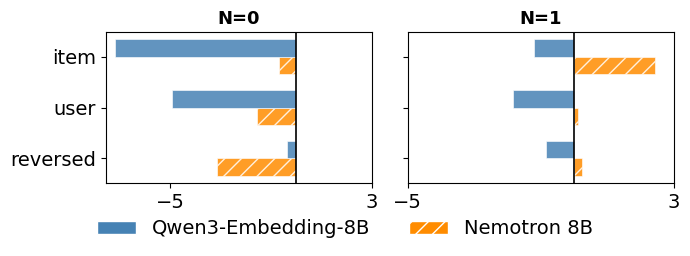

In [9]:
import matplotlib.lines as mlines
from matplotlib.patches import Patch

# prefix sensitivity bar chart
score_name  = "ndcg"
models_plot = {
    "[E] Qwen3 (8B)":     "Qwen3-Embedding-8B",
    "[E] Nemotron (8B)": "Nemotron 8B"
}
prefix_raw    = ["product", "user", "ablation"][::-1]
prefix_labels = ["item", "user", "reversed"][::-1]
n_conditions  = {"profile": "N=0", "separate_1-sample": "N=1"}

d_imp = {}
for m, mlabel in models_plot.items():
    d_imp[mlabel] = {}
    dict_stat_  = loader.add_statistics(dict_data, f"{m}:::default")
    dict_table_ = loader.reshape_data(dict_stat_, score_name)
    for p, d in dict_table_.items():
        if p not in n_conditions:
            continue
        nlabel = n_conditions[p]
        df     = d["mean"]
        rows   = [i for i in df.index if m in i]
        df_    = df.loc[rows]
        s_base = df_.loc[f"{m}:::default"]
        changes = []
        for pkey in prefix_raw:
            row_key = f"{m}:::{pkey}"
            if row_key in df_.index:
                changes.append(((df_.loc[row_key] / s_base) - 1).mean() * 100)
            else:
                changes.append(float("nan"))
        d_imp[mlabel][nlabel] = changes

model_colors = {"Qwen3-Embedding-8B": "steelblue", "Nemotron 8B": "teal"}
model_colors = {"Qwen3-Embedding-8B": "steelblue", "Nemotron 8B": "darkorange"}
model_hatch  = {"Qwen3-Embedding-8B": "",         "Nemotron 8B": "//"}
mlabels    = list(models_plot.values())[::-1]
y_pos      = np.arange(len(prefix_labels))
bar_height = 0.35
p_band     = 5

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9), sharey=True)
for ax, nlabel in zip(axes, ["N=0", "N=1"]):
    for j, mlabel in enumerate(mlabels):
        vals   = d_imp[mlabel].get(nlabel, [float("nan")] * len(prefix_labels))
        offset = (j - (len(mlabels) - 1) / 2) * bar_height
        ax.barh(y_pos + offset, vals, bar_height,
                color=model_colors[mlabel], hatch=model_hatch[mlabel],
                alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=1.2, linestyle="-")
    ax.set_title(nlabel, fontsize=FS["title"], fontweight="bold")
    ax.tick_params(labelsize=14)
    ax.set_xticks([-5,3])

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(prefix_labels, fontsize=14)

# Lift x-label so it does not overlap the legend beneath it
#fig.supxlabel("Avg. relative change (%)", fontsize=14, y=0.27)

legend_handles = [
    Patch(facecolor=model_colors[m], hatch=model_hatch[m],
          edgecolor="white", label=m)
    for m in mlabels
]
fig.legend(handles=legend_handles[::-1], loc="lower center", ncol=2,
           fontsize=14, frameon=False, bbox_to_anchor=(0.5, 0.1))
fig.tight_layout(rect=[0, 0.20, 1, 1])
fig.savefig(f"{dir_figs}/prefix_sensitivity.pdf", bbox_inches="tight", dpi=300)
plt.show()